## Simulation and the Distribution

Notebook introduces some methods to find the ergodic distribution in the context of the neoclassical growth model with endogenous labor specified in the module `endog_labor.jl`.



In [1]:
include("endog_labor.jl");
include("distribution.jl") 

ergodic_dist (generic function with 1 method)

### 1. Introduction
The overall state $(z, k)$ follows a Markov process which combines the exogenous Markov process for $z$ and the endogenous policy $k'(z, k)$. There are two main options to characterize the _ergodic properties_ of the Markov process:

1. Monte carlo simulation - naive and slow to converge but robust.
2. Explicitly solve for stationary distribution - faster but not always feasible

### 2. Monte Carlo
First let's compute the basic objects we will need. The function `solveNeoclassical()` takes as input the parameters for the model and the size of the grid and returns Chebyshev polynomial representations of the policy functions:

In [96]:
@unpack α, δ, β = Params()

# define production function to back out k'(k, z) from policies
F(z, k, n) = z .* k.^α .* n.^(1.0 - α) .+ (1.0 - δ) .* k


# compute  the discretized AR(1) process explicitly
z, pr, Π = ProductivityProcess(Params())

# steady state values
c̄, n̄, k̄ = SteadyState(Params(), F)

# precalculate CDFs:
Π_cdf = cumsum(Π, dims = 2);

nq, cq, k, basis = solveNeoclassical(Params(), 15);


# get the explicit policy funtions:
c = funeval(cq, basis, k);
n = funeval(nq, basis, k);
k₊ = F(z', k, n) - c;

# Get chebyshev representation of policy function for capital
k₊q = cheb_interp(k₊, basis);

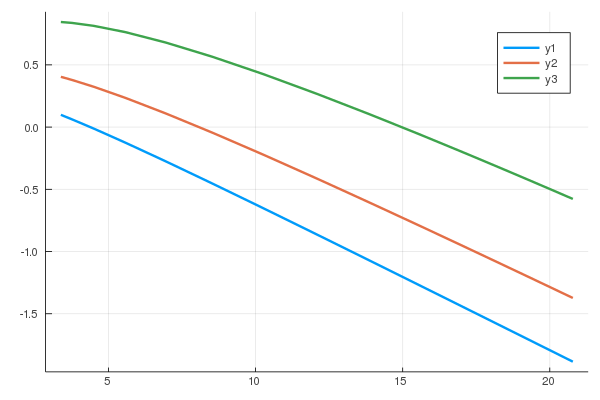

In [97]:
# brief check to make sure everything is working and grids are ok
using Plots
gr(fmt=:png);
plot(k, k₊ .- k, lw = 2)

Let's automate a function that returns the values of a function approximated at query points `x` with chebyshev coefficients `q`

In [98]:
function cheb_chebval(x, q; basis = basis)
    (BasisMatrix(basis, Direct(), [x]).vals[1]*q)[1] #dirty fix to return float instead of Array
end

cheb_chebval (generic function with 1 method)

Now define a function that given some (index) for $z$, the current state, and $k$ does a new draw to update the state

In [99]:
function update(zi, z, k, k₊q; basis = basis)
    
    # Find the value of capital at query point k efficiently 
    k₊ = cheb_chebval(k, k₊q[:, zi])
    #k₊ = funeval(k₊q[:, zi], basis, k)
    # do random draw to find the state:
    r = rand()
    zi₊ = 0
    for i in 1:length(z)
        if r < Π_cdf[zi, i]
            zi₊ = i
            break
        end
    end
    
    return zi₊, k₊
end


update (generic function with 1 method)

Now try to compute the means givens starting points for $(z, k)$

In [5]:
function mc_means(k₀, zi₀, z, k₊q, N, Ndrop)
    
    k = k₀
    zi = zi₀
    
    for _ in 1:Ndrop
        # burn-in to acconunt for non-randomness of initial condition
        zi, k = update(zi, z, k,  k₊q)
    end
    
    ksum = 0.
    nsum = 0.
    csum = 0.
    
    for _ in 1:(N - Ndrop)

        ksum += k
        nsum += cheb_chebval(k, nq[:, zi])
        csum += cheb_chebval(k, cq[:, zi])
        #nsum += funeval(nq[:, zi], basis, k)
        #csum += funeval(cq[:, zi], basis, k)
        zi, k = update(zi, z, k,  k₊q)
    end
    
    # return averages
    return ksum/(N - Ndrop), nsum/(N - Ndrop), csum/(N - Ndrop)
end

mc_means (generic function with 1 method)

In [6]:
using BenchmarkTools
@btime mc_means(k̄, 1, z,  k₊q, 1000000, 10000)

  3.953 s (65579106 allocations: 4.54 GiB)


(8.67470560711843, 0.8617593497773293, 1.7631435902834753)

It is not very efficient yet. We could probably do better if we avoided the overhead of `BasisMatrices` and somehow try to avoid computing the whole matrix in each iteration but I do not know enough about Chebyshev interpolation to get there now. However, this is better than using the built-in `funeval` function, as I show below:

In [90]:
function update(zi, z, k, k₊q; basis = basis)
    
    # Find the value of capital at query point k efficiently 
    k₊ = funeval(k₊q[:, zi], basis, k)
    
    # do random draw to find the state:
    r = rand()
    zi₊ = 0
    for i in 1:length(z)
        if r < Π_cdf[zi, i]
            zi₊ = i
            break
        end
    end
    
    return zi₊, k₊
end

function mc_means(k₀, zi₀, z, k₊q, N, Ndrop)
    
    k = k₀
    zi = zi₀
    
    for _ in 1:Ndrop
        # burn-in to acconunt for non-randomness of initial condition
        zi, k = update(zi, z, k,  k₊q)
    end
    
    ksum = 0.
    nsum = 0.
    csum = 0.
    
    for _ in 1:(N - Ndrop)

        ksum += k
        nsum += funeval(nq[:, zi], basis, k)
        csum += funeval(cq[:, zi], basis, k)
        zi, k = update(zi, z, k,  k₊q)
    end
    
    # return averages
    return ksum/(N - Ndrop), nsum/(N - Ndrop), csum/(N - Ndrop)
end


mc_means (generic function with 1 method)

In [25]:
@btime mc_means(k̄, 1, z,  k₊q, 1000000, 10000)

  6.342 s (115251358 allocations: 8.17 GiB)


(8.682445811310492, 0.8617481850597194, 1.7642831384762914)

### 3. Explictly solving for the distribution

We will explore the simplest way to do this - where we discretize the state space and use lotteries.

First create grid on which we will compute the distribution, it is low cost for this to be fine:

In [64]:
Ndist = 2000
klow, khigh = 0.4 * k̄, 2.5 * k̄
kdense = range(klow, khigh, length = Ndist);

Now we need to discretize the policy rule $k'$ - why? Because for a given point $(z, k)$ the policy will usually lie between two points of the discretized policy rule. 

**Solution**: replace policy rule with a lottery policy rule that picks two neighboring gridpoints each with some positive probability, such that the probability averages out to be right.

In [65]:
function interpolate_policy(x, xq)
    """ 
    Parameters
    ----------
    x  : array(n), ascending data points
    xq  : array(nq), ascending query points
    
    Returns
    ---------
    xqi  : array(nq), indices of lower bracketing gridpoints
    pi   : array(nq), weights on lower bracketing gridpoints
    """
    
    nq, n = size(xq)[1], size(x)[1]
    xqi = Array{Int64}(undef, nq)
    pi = Array{Float64}(undef, nq)
    
    xi = 1
    xlow = x[1]
    xhigh = x[2]
    for i in 1:nq
        xq_cur = xq[i]
        while xi < n - 2
            if xhigh >= xq_cur
                break
            end
            xi += 1
            xlow = xhigh
            xhigh = x[xi + 1]
        end
        xqi[i] = xi
        pi[i] = (xhigh - xq_cur) / (xhigh - xlow)
    end
    return xqi, pi
end
    
    

interpolate_policy (generic function with 1 method)

In [66]:
k₊dense = funeval(k₊q, basis, kdense);
k₊i = Array{Int64}(undef, length(kdense), length(z))
pi_k = similar(k₊dense)

for i in 1:length(z)
    k₊i[:, i], pi_k[:, i] =  interpolate_policy(kdense, k₊dense[:, i]) 
end

In [67]:
k₊i[2000, 1], pi_k[2000, 1]

(1783, 0.006312746888301778)

In [68]:
k₊dense[2000, 1]

18.940412946116602

In [69]:
kdense[1783], kdense[1784]

(18.93171471467924, 18.940468204683388)

This says that we go between 20 and 21 - with most of the weight on 20 bc we are closer to it

Now, we turn to the second step which is defining a function to update the distribution:

In [70]:
function forward_iterate(D, Π, k₊i, pi_k)
    Dnew = zeros(size(D))
    # First update using endogenous capital policy
    for zi in 1:size(D)[2]
        for ki in 1:size(D)[1]
            i = k₊i[ki, zi]
            pi = pi_k[ki, zi]
            d = D[ki, zi]
            Dnew[i, zi] += d*pi
            Dnew[i+1, zi] += d*(1-pi)
        end
    end
    # Now update the exogenous state using Markov matrix \Pi
    return Dnew * Π
end

forward_iterate (generic function with 1 method)

Finally, we define a function to compute the ergodic distribution of the economy

In [71]:
function ergodic_dist(Π, k₊i, pi_k; maxit = 10000, tol = 1E-10)
    # start by getting stationary distribution of z
    pr = stationary(Π)
    # assume uniform distribution on k for the initial distribution
    nK = size(k₊i)[1]
    D = pr.*fill(1/nK, nK)
    for it in 1:maxit
        Dnew = forward_iterate(D, Π, k₊i, pi_k)
        if mod(it, 20) ≈ 0 && norm(Dnew - D) < tol
            #println("Convergence after $it iterations!")
            break
        end
        D = Dnew
    end
    return D
end

ergodic_dist (generic function with 1 method)

In [72]:
D = ergodic_dist(Π, k₊i, pi_k );

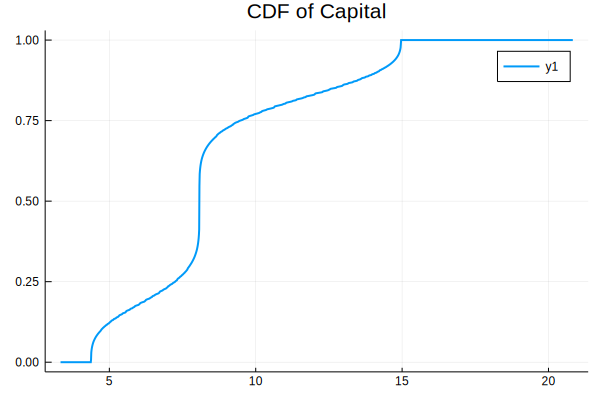

In [73]:
using Plots
plot(kdense, cumsum(sum(D, dims = 2), dims = 1), title = "CDF of Capital",
     lw = 2)

Let's plot CDF conditional on each state

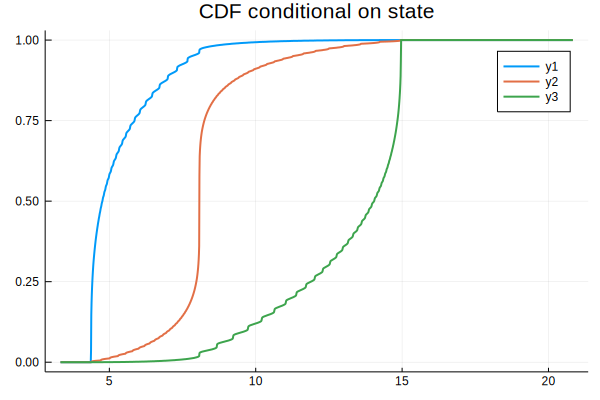

In [74]:
plot(kdense, cumsum(D, dims = 1) ./ pr, lw = 2, 
    title = "CDF conditional on state")

**Remarks**:
1. You can easily see the fixed points of the capital policy rule for each state here - that is the point where the slope of the CDF approaches infinity, reflecting how capital steadily approaches these values conditional on the state persisting. 
2. Moreover the steps correspond to people that were initially in the steady state and then they get hit by the shock and start to accumulate (or decumulate) as they move to the high (or low) state.

### Computing some moments

In [75]:
ndense = funeval(nq, basis, kdense)
cdense = funeval(cq, basis, kdense);

In [76]:
@btime sum(D .* ndense)

  4.620 μs (5 allocations: 47.02 KiB)


0.8617938283059274

In [77]:
@btime sum( D .⋅ ndense )

  4.332 μs (5 allocations: 47.02 KiB)


0.8617938283059274

Looks like the second method is slightly faster, so we will stick to that.

In [78]:
n_mean = sum(D .⋅ ndense)
c_mean = sum(D .⋅ cdense)
k_mean = sum(D .⋅ kdense)

8.647482190529324

In [79]:
k_mean, c_mean, n_mean

(8.647482190529324, 1.7607231516455926, 0.8617938283059274)

## Digression - Euler equation errors

I seem to be getting some differences with Matt's code here. So it's good opportunity to check some Euler equation errors.
### Euler equation errors - static
Let's first look at the errors from the static EE:

$$ v'(n(z,k)) = F_n(z, k, n(z,k)) u'(c(z,k)) $$

In [55]:
# production and utility functions
F(z, k, n) = z .* k.^α .* n.^(1.0 - α) .+ (1.0 - δ) .* k
Fk(z, k, n) =  α .* z .* (n ./ k).^(1.0 - α) .+ (1.0 - δ)
Fn(z, k, n) = (1.0 - α) .* z .* (k ./ n).^α
up(c) = 1.0 ./ c
up_inv(c) = 1.0 ./ c #this doesn't really have to be broadcasted bc it only takes scalars as inputs
vp(n) = n # frisch elasticity of one

vp (generic function with 1 method)

In [56]:
kdense = range(k[1], k[end], length = 1000)
n = funeval(nq, basis, kdense)
c = funeval(cq, basis, kdense)
err = up_inv(vp.(n) ./ Fn(z', kdense, n) )./c .- 1 ;

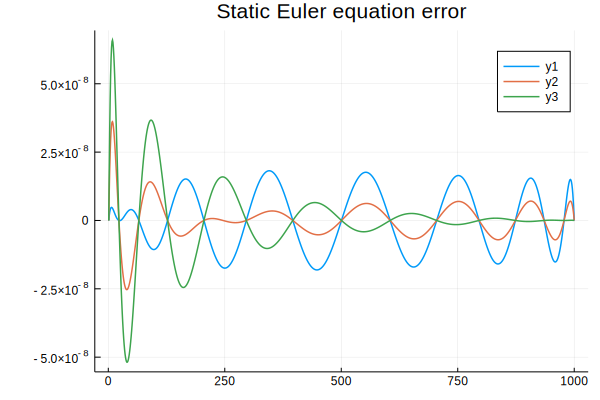

In [31]:
using Plots
plot(err, lw = 1.5, title = "Static Euler equation error")

### Euler Equation errors - dynamic

(1000, 3)

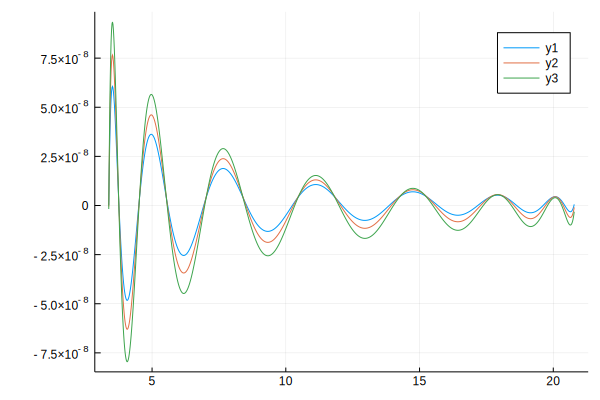

In [32]:
k₊ = F(z', kdense, n) - c
c_right = similar(c)
print(size(c_right))
for (i, zi) in enumerate(z)
    c_inner = funeval(cq, basis, k₊[:, i])
    n_inner = funeval(nq, basis, k₊[:, i])
    c_right[:, i] = up_inv(β * Π[i,:]' * ((Fk(z', k₊[:, i], n_inner).*up(c_inner)))')
end
err = c_right ./ c .- 1

plot(kdense, err)

Things are clearly wrong, I have to go back and check

**Update**: I think I have fixed it so now let's check again 

**Remark** Plots above look fine now beecause I ran the notebook after fixing it, but originally IT WAS BAD!

In [21]:
kdense = range(k[1], k[end], length = 1000)
n = funeval(nq, basis, kdense)
c = funeval(cq, basis, kdense)
err = up_inv(vp.(n) ./ Fn(z', kdense, n) )./c .- 1 ;

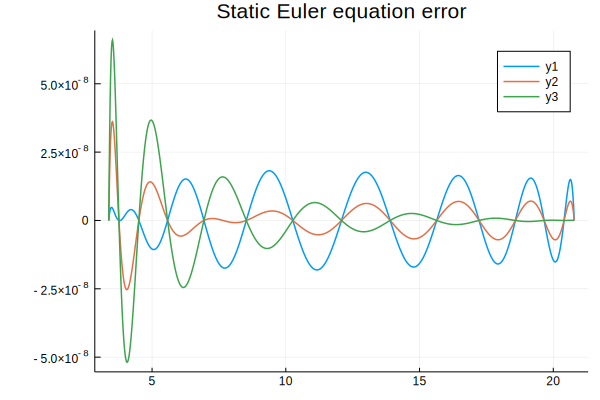

In [23]:
plot(kdense, err, lw = 1.5, title = "Static Euler equation error")

(1000, 3)

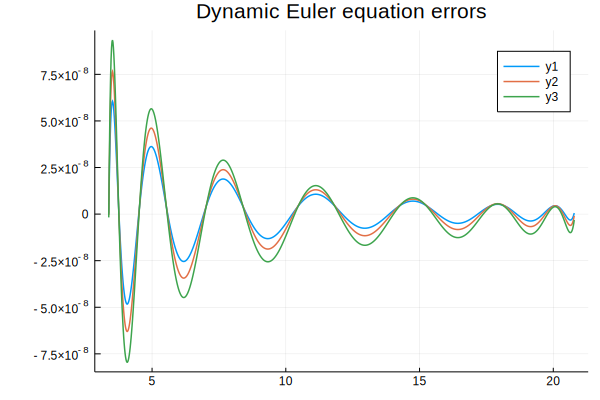

In [26]:
k₊ = F(z', kdense, n) - c
c_right = similar(c)
print(size(c_right))
for (i, zi) in enumerate(z)
    c_inner = funeval(cq, basis, k₊[:, i])
    n_inner = funeval(nq, basis, k₊[:, i])
    c_right[:, i] = up_inv(β * Π[i,:]' * ((Fk(z', k₊[:, i], n_inner).*up(c_inner)))')
end
err = c_right ./ c .- 1

plot(kdense, err, lw = 1.5, title = "Dynamic Euler equation errors")

Uffff, ok now we are better and things are consistent with what Matt has! Enough for today!

**Takeaway**: Euler equation errors are VERY useful to check your work!

## Back to computing some moments

Suppose now we want to compute the autocorrelation of capital in this economy:
$$
\text{Corr}(k_t, k_{t+1}) = \frac{E[k_tk_{t+1}] - E[k_t]^2}{E[k_t^2] - E[k_t]^2}
$$

Let's use the distribution to compute each moment:

In [83]:
k_k1 = sum(D .⋅ (kdense .* k₊dense))

83.41148895766756

In [86]:
ksq_mean = sum( D .⋅ kdense .^ 2)

83.4269225359932

In [87]:
k_mean

8.647482190529324

In [89]:
auto_corr = (k_k1 - k_mean^2)/(ksq_mean - k_mean^2)

0.9982153533545075

If we want to compute more complicated moments like autocorrelation at horizon 5, then there is no longer any direct way to compute this using the distribution, so in this case we could proceed by Monte Carlo, but I would like to find a way to avoid doing this!

In [124]:
function mc_auto5(k₀, zi₀, z, k₊q, N, Ndrop)
    
    k = k₀
    zi = zi₀
    
    for _ in 1:Ndrop
        # burn-in to acconunt for non-randomness of initial condition
        zi, k = update(zi, z, k,  k₊q)
    end

    ks = zeros(N - Ndrop)
    
    for i in 1:N-Ndrop
        zi, k = update(zi, z, k,  k₊q)
        ks[i] = k
    end
    
    k_mean = sum(ks) / (N - Ndrop)
    ksq_mean = (ks ⋅ ks) / (N - Ndrop)
    k_k5_mean = ks[6:end] ⋅ ks[1:end-5] / (N - Ndrop)
    
    return ( k_k5_mean - k_mean^2) / (ksq_mean - k_mean^2)
end


mc_auto5 (generic function with 1 method)

In [125]:
mc_auto5(k̄, 1, z,  k₊q, 1000000, 10000)

0.9641188904498025

In [126]:
@time mc_auto5(k̄, 1, z,  k₊q, 1000000, 10000)

  1.444644 seconds (25.98 M allocations: 1.616 GiB, 10.80% gc time)


0.9638551322557892